# Proyek Klasifikasi Gambar: Natural Scene Classification

- **Nama:** Maulida Cahya Kurnia
- **Email:** cahyamaulida011@gmail.com
- **ID Dicoding:** maulidacahya

## Pendahuluan

Project ini bertujuan untuk membangun model klasifikasi gambar menggunakan Convolutional Neural Network (CNN). Model dikembangkan untuk mengenali enam kategori gambar natural scene, yaitu:

- buildings
- forest
- glacier
- mountain
- sea
- street

Dataset yang digunakan adalah Intel Image Classification. Dataset ini dipilih karena memiliki jumlah gambar lebih dari 1.000, terdiri dari lebih dari 3 kelas, dan tidak termasuk dataset yang dilarang seperti Rock Paper Scissors atau X-Ray.

Project ini disusun secara bertahap, mulai dari pemuatan dataset, eksplorasi data, preprocessing gambar, pembagian data menjadi training set, validation set, dan testing set, pembangunan model CNN, evaluasi model, visualisasi accuracy dan loss, hingga penyimpanan model ke dalam format SavedModel, TensorFlow Lite, dan TensorFlow.js.

## Tujuan Project

Project ini bertujuan untuk membangun model klasifikasi gambar yang mampu mengenali enam kategori natural scene, yaitu buildings, forest, glacier, mountain, sea, dan street.

Secara teknis, project ini dilakukan untuk:

1. Menggunakan dataset gambar natural scene dengan jumlah data yang cukup besar.
2. Melakukan eksplorasi dataset untuk melihat jumlah gambar, distribusi kelas, dan contoh citra dari setiap kelas.
3. Mempersiapkan data dengan resize gambar, normalisasi pixel, validation split, dan data augmentation.
4. Membangun model CNN berbasis Sequential dengan layer Conv2D dan MaxPooling2D.
5. Melatih model untuk mengklasifikasikan gambar ke dalam enam kelas.
6. Mengevaluasi performa model menggunakan data test yang terpisah dari data training.
7. Menampilkan visualisasi accuracy dan loss untuk melihat proses pembelajaran model.
8. Melakukan evaluasi tambahan menggunakan classification report dan confusion matrix.
9. Menyimpan model ke dalam format SavedModel, TensorFlow Lite, dan TensorFlow.js.
10. Melakukan inference pada beberapa gambar test untuk melihat hasil prediksi model secara langsung.

## Import Semua Packages/Library yang Digunakan

Pada tahap ini, library yang dibutuhkan akan diimpor. Library utama yang digunakan adalah TensorFlow/Keras untuk pembangunan model CNN, NumPy dan Matplotlib untuk pengolahan data serta visualisasi, PIL untuk membaca informasi gambar, dan Scikit-learn untuk evaluasi model.

In [1]:
# Standard library
import os
import shutil
import zipfile
import random
from pathlib import Path

# Data processing
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt

# Image processing
from PIL import Image

# Google Colab
from google.colab import drive

# TensorFlow / Keras
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

# Evaluation
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

print("TensorFlow version:", tf.__version__)
print("GPU devices:", tf.config.list_physical_devices("GPU"))

TensorFlow version: 2.19.0
GPU devices: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## Catatan GPU

In [2]:
if len(tf.config.list_physical_devices("GPU")) == 0:
    print("GPU tidak terdeteksi. Untuk training, aktifkan Runtime > Change runtime type > T4 GPU.")
else:
    print("GPU terdeteksi. Training siap dijalankan.")

GPU terdeteksi. Training siap dijalankan.


## Deskripsi Dataset

Dataset yang digunakan adalah Intel Image Classification. Dataset ini berisi gambar natural scene yang terbagi ke dalam enam kelas, yaitu buildings, forest, glacier, mountain, sea, dan street.

## Setup Direktori Project

Pada tahap ini dilakukan konfigurasi direktori project di Google Drive. Folder utama project berada pada `Drive Saya/natural_scene_classification_cnn`.

Direktori ini digunakan untuk menyimpan dataset, hasil evaluasi, serta model akhir dalam format SavedModel, TensorFlow Lite, dan TensorFlow.js.

In [3]:
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


In [4]:
PROJECT_NAME = "natural_scene_classification_cnn"

BASE_DIR = Path("/content/drive/MyDrive") / PROJECT_NAME

DATA_DIR = BASE_DIR / "data"
RAW_DIR = DATA_DIR / "raw"
EXTRACTED_DIR = DATA_DIR / "extracted"

REPORTS_DIR = BASE_DIR / "reports"
FIGURES_DIR = REPORTS_DIR / "figures"

SAVED_MODEL_DIR = BASE_DIR / "saved_model"
TFLITE_DIR = BASE_DIR / "tflite"
TFJS_DIR = BASE_DIR / "tfjs_model"

PROJECT_DIRS = [
    BASE_DIR,
    DATA_DIR,
    RAW_DIR,
    EXTRACTED_DIR,
    REPORTS_DIR,
    FIGURES_DIR,
    SAVED_MODEL_DIR,
    TFLITE_DIR,
    TFJS_DIR,
]

for directory in PROJECT_DIRS:
    directory.mkdir(parents=True, exist_ok=True)

print("BASE_DIR:", BASE_DIR)
print("BASE_DIR exists:", BASE_DIR.exists())

BASE_DIR: /content/drive/MyDrive/natural_scene_classification_cnn
BASE_DIR exists: True


In [5]:
print("Isi BASE_DIR:")
print(os.listdir(BASE_DIR))

print("\nIsi DATA_DIR:")
print(os.listdir(DATA_DIR))

print("\nIsi RAW_DIR:")
print(os.listdir(RAW_DIR))

print("\nIsi EXTRACTED_DIR:")
print(os.listdir(EXTRACTED_DIR))

Isi BASE_DIR:
['data', 'tfjs_model', 'reports', 'tflite', 'saved_model', 'notebook.ipynb']

Isi DATA_DIR:
['extracted', 'raw']

Isi RAW_DIR:
['archive (3).zip']

Isi EXTRACTED_DIR:
[]


## Ekstraksi Dataset

Dataset disimpan dalam bentuk file ZIP pada folder `data/raw`. File ZIP kemudian diekstrak ke folder `data/extracted`.

Jika folder hasil ekstraksi lama sudah ada, folder tersebut akan dibersihkan terlebih dahulu agar struktur dataset tidak tercampur dengan hasil ekstraksi sebelumnya.

In [6]:
zip_files = list(RAW_DIR.glob("*.zip"))

print("ZIP files ditemukan di RAW_DIR:")
for zip_file in zip_files:
    print("-", zip_file.name)

if len(zip_files) == 0:
    raise FileNotFoundError(
        "Tidak ada file ZIP di RAW_DIR. "
        "Upload file dataset ZIP ke folder Drive Saya/natural_scene_classification_cnn/data/raw/ terlebih dahulu."
    )

zip_path = zip_files[0]
print("ZIP yang digunakan:", zip_path)

if EXTRACTED_DIR.exists():
    shutil.rmtree(EXTRACTED_DIR)

EXTRACTED_DIR.mkdir(parents=True, exist_ok=True)

with zipfile.ZipFile(zip_path, "r") as zip_ref:
    zip_ref.extractall(EXTRACTED_DIR)

print("Berhasil extract ulang ke:", EXTRACTED_DIR)

print("\nIsi EXTRACTED_DIR:")
print(os.listdir(EXTRACTED_DIR))

ZIP files ditemukan di RAW_DIR:
- archive (3).zip
ZIP yang digunakan: /content/drive/MyDrive/natural_scene_classification_cnn/data/raw/archive (3).zip
Berhasil extract ulang ke: /content/drive/MyDrive/natural_scene_classification_cnn/data/extracted

Isi EXTRACTED_DIR:
['seg_pred', 'seg_test', 'seg_train']


## Penentuan Path Dataset

Setelah dataset berhasil diekstrak, path untuk data training, testing, dan prediction ditentukan berdasarkan struktur folder dataset.

In [7]:
TRAIN_DIR = EXTRACTED_DIR / "seg_train" / "seg_train"
TEST_DIR = EXTRACTED_DIR / "seg_test" / "seg_test"
PRED_DIR = EXTRACTED_DIR / "seg_pred" / "seg_pred"

print("Train dir:", TRAIN_DIR)
print("Test dir :", TEST_DIR)
print("Pred dir :", PRED_DIR)

print("\nTrain exists:", TRAIN_DIR.exists())
print("Test exists :", TEST_DIR.exists())
print("Pred exists :", PRED_DIR.exists())

if not TRAIN_DIR.exists() or not TEST_DIR.exists():
    raise FileNotFoundError(
        "Path dataset belum benar. Pastikan hasil extract memiliki struktur "
        "seg_train/seg_train dan seg_test/seg_test."
    )

Train dir: /content/drive/MyDrive/natural_scene_classification_cnn/data/extracted/seg_train/seg_train
Test dir : /content/drive/MyDrive/natural_scene_classification_cnn/data/extracted/seg_test/seg_test
Pred dir : /content/drive/MyDrive/natural_scene_classification_cnn/data/extracted/seg_pred/seg_pred

Train exists: True
Test exists : True
Pred exists : True


## Eksplorasi Jumlah Gambar per Kelas

Tahap ini dilakukan untuk memastikan dataset memiliki jumlah gambar yang cukup dan setiap kelas memiliki data yang tersedia.

In [8]:
def count_images_per_class(directory):
    class_counts = {}

    for class_folder in sorted(directory.iterdir()):
        if class_folder.is_dir():
            image_files = [
                file for file in class_folder.iterdir()
                if file.suffix.lower() in [".jpg", ".jpeg", ".png"]
            ]
            class_counts[class_folder.name] = len(image_files)

    return class_counts


train_counts = count_images_per_class(TRAIN_DIR)
test_counts = count_images_per_class(TEST_DIR)

print("Jumlah gambar TRAIN:")
for class_name, count in train_counts.items():
    print(f"{class_name}: {count}")

print("\nJumlah gambar TEST:")
for class_name, count in test_counts.items():
    print(f"{class_name}: {count}")

print("\nTotal TRAIN:", sum(train_counts.values()))
print("Total TEST :", sum(test_counts.values()))
print("TOTAL DATA :", sum(train_counts.values()) + sum(test_counts.values()))

Jumlah gambar TRAIN:
buildings: 2191
forest: 2271
glacier: 2404
mountain: 2512
sea: 2274
street: 2382

Jumlah gambar TEST:
buildings: 437
forest: 474
glacier: 553
mountain: 525
sea: 510
street: 501

Total TRAIN: 14034
Total TEST : 3000
TOTAL DATA : 17034


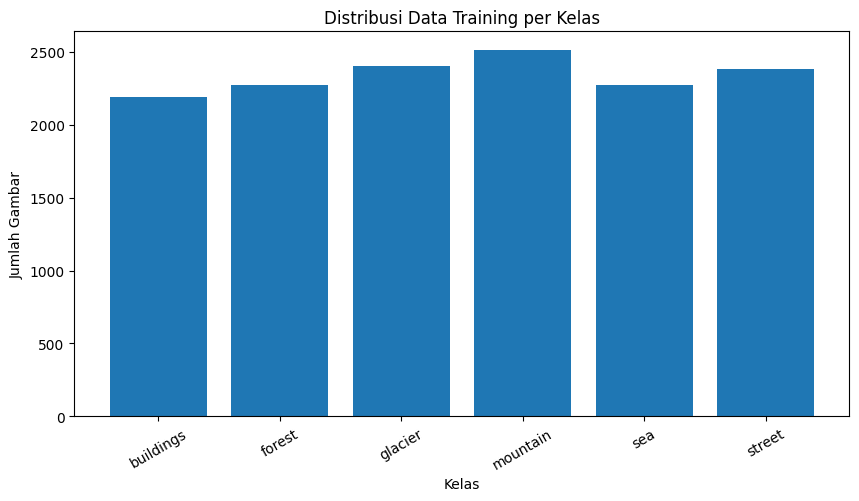

In [9]:
plt.figure(figsize=(10, 5))
plt.bar(train_counts.keys(), train_counts.values())
plt.title("Distribusi Data Training per Kelas")
plt.xlabel("Kelas")
plt.ylabel("Jumlah Gambar")
plt.xticks(rotation=30)
plt.show()

## Contoh Gambar Dataset

Beberapa sampel gambar ditampilkan untuk memahami karakteristik visual dari setiap kelas.

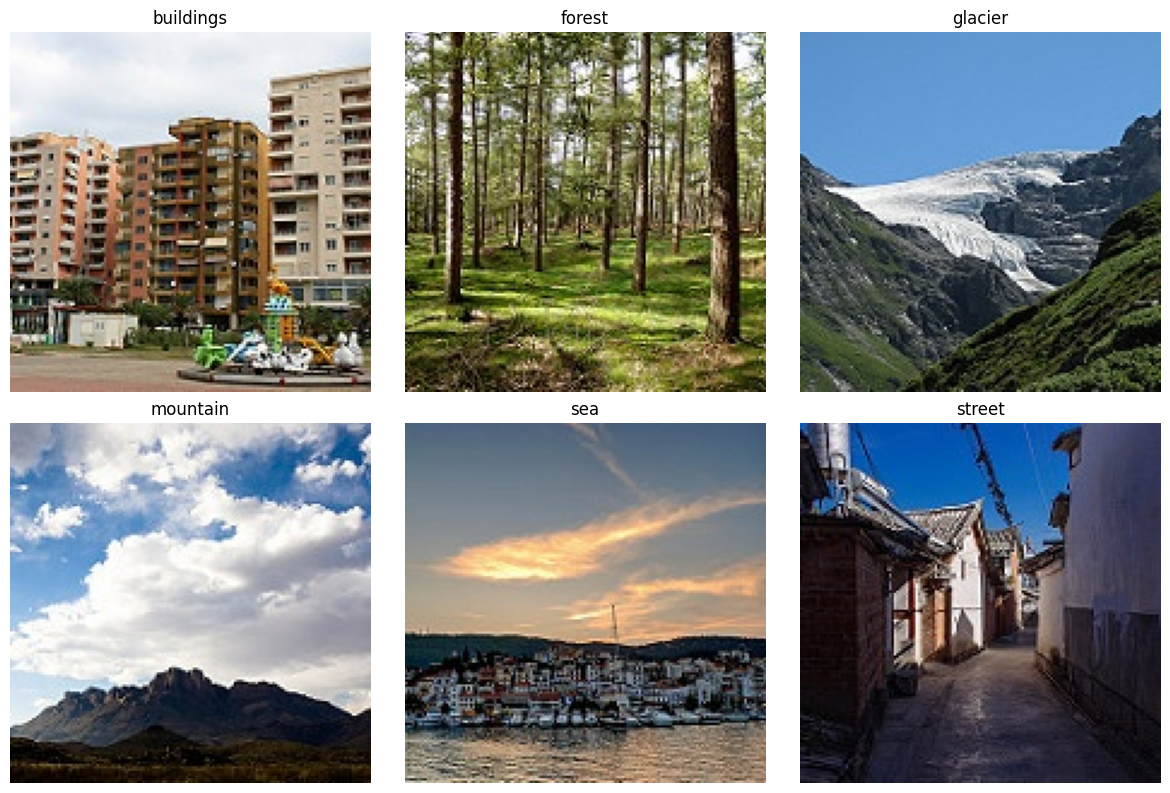

In [10]:
plt.figure(figsize=(12, 8))

for i, class_name in enumerate(sorted(train_counts.keys())):
    class_dir = TRAIN_DIR / class_name
    image_files = list(class_dir.glob("*.jpg"))
    sample_image = random.choice(image_files)

    img = Image.open(sample_image)

    plt.subplot(2, 3, i + 1)
    plt.imshow(img)
    plt.title(class_name)
    plt.axis("off")

plt.tight_layout()
plt.show()

## Data Preparation dan Preprocessing

Pada tahap ini dilakukan persiapan dan preprocessing data gambar sebelum digunakan untuk training model. Proses yang dilakukan meliputi resize gambar ke ukuran 150x150 piksel, normalisasi nilai piksel ke rentang 0-1, pembagian data training menjadi training set dan validation set menggunakan `validation_split`, serta data augmentation pada training data.

Data augmentation hanya diterapkan pada data training untuk meningkatkan variasi data dan mengurangi risiko overfitting.

### 1. Data Generator

In [11]:
IMG_SIZE = (150, 150)
BATCH_SIZE = 32

train_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2,
    rotation_range=25,
    zoom_range=0.2,
    width_shift_range=0.1,
    height_shift_range=0.1,
    shear_range=0.1,
    horizontal_flip=True,
    fill_mode='nearest'
)

test_datagen = ImageDataGenerator(rescale=1./255)

### 2. Train Generator

In [12]:
train_generator = train_datagen.flow_from_directory(
    TRAIN_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='training'
)

Found 11230 images belonging to 6 classes.


### 3. Validation Generator

In [13]:
val_generator = train_datagen.flow_from_directory(
    TRAIN_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation'
)

Found 2804 images belonging to 6 classes.


### 4. Test Generator

In [14]:
test_generator = test_datagen.flow_from_directory(
    TEST_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

Found 3000 images belonging to 6 classes.


### 5. Cek class mapping

In [15]:
print("Class mapping:", train_generator.class_indices)

Class mapping: {'buildings': 0, 'forest': 1, 'glacier': 2, 'mountain': 3, 'sea': 4, 'street': 5}


## Modelling

Model yang digunakan adalah Convolutional Neural Network berbasis Sequential. Model ini menggunakan beberapa layer Conv2D dan MaxPooling2D.

Untuk meningkatkan stabilitas training dan mengurangi overfitting, model juga menggunakan BatchNormalization dan Dropout.

### 1. Model CNN

In [16]:
model = models.Sequential([
    layers.Input(shape=(150, 150, 3)),

    layers.Conv2D(32, (3, 3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(128, (3, 3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(256, (3, 3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),

    layers.GlobalAveragePooling2D(),

    layers.Dense(256, activation='relu'),
    layers.Dropout(0.5),

    layers.Dense(train_generator.num_classes, activation='softmax')
])

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 150, 150, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 150, 150, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 75, 75, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 75, 75, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 75, 75, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 37, 37, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 37, 37, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 37, 37, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 18, 18, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 18, 18, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 18, 18, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 9, 9, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 256)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │        65,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 6)              │         1,542 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 457,670 (1.75 MB)

 Trainable params: 456,710 (1.74 MB)

 Non-trainable params: 960 (3.75 KB)

### 2. Compile model

In [17]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

### 3. Callback

In [18]:
checkpoint_path = BASE_DIR / "best_model.keras"

callbacks = [
    ModelCheckpoint(
        filepath=str(checkpoint_path),
        monitor='val_accuracy',
        save_best_only=True,
        mode='max',
        verbose=1
    ),
    EarlyStopping(
        monitor='val_accuracy',
        patience=7,
        restore_best_weights=True,
        mode='max',
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.3,
        patience=3,
        min_lr=1e-6,
        verbose=1
    )
]

### 4. Training

In [19]:
EPOCHS = 30

history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=EPOCHS,
    callbacks=callbacks
)

Epoch 1/30
351/351 ━━━━━━━━━━━━━━━━━━━━ 0s 362ms/step - accuracy: 0.5422 - loss: 1.2206
Epoch 1: val_accuracy improved from None to 0.33702, saving model to /content/drive/MyDrive/natural_scene_classification_cnn/best_model.keras

Epoch 1: finished saving model to /content/drive/MyDrive/natural_scene_classification_cnn/best_model.keras
351/351 ━━━━━━━━━━━━━━━━━━━━ 172s 449ms/step - accuracy: 0.6045 - loss: 1.0495 - val_accuracy: 0.3370 - val_loss: 2.2041 - learning_rate: 0.0010
Epoch 2/30
351/351 ━━━━━━━━━━━━━━━━━━━━ 0s 327ms/step - accuracy: 0.7003 - loss: 0.8227
Epoch 2: val_accuracy improved from 0.33702 to 0.46184, saving model to /content/drive/MyDrive/natural_scene_classification_cnn/best_model.keras

Epoch 2: finished saving model to /content/drive/MyDrive/natural_scene_classification_cnn/best_model.keras
351/351 ━━━━━━━━━━━━━━━━━━━━ 142s 406ms/step - accuracy: 0.7160 - loss: 0.7870 - val_accuracy: 0.4618 - val_loss: 1.5948 - learning_rate: 0.0010
Epoch 3/30
351/351 ━━━━━━━━━━━━

## Evaluasi Model pada Test Set

Setelah proses training selesai, model dievaluasi menggunakan test set. Test set tidak digunakan selama proses training sehingga hasil evaluasi ini digunakan untuk mengukur kemampuan generalisasi model pada data baru.

### 1. Evaluasi Test Set

In [20]:
test_loss, test_accuracy = model.evaluate(test_generator)

print(f"Test Loss     : {test_loss:.4f}")
print(f"Test Accuracy : {test_accuracy:.4f}")

94/94 ━━━━━━━━━━━━━━━━━━━━ 12s 131ms/step - accuracy: 0.8833 - loss: 0.3473
Test Loss     : 0.3473
Test Accuracy : 0.8833


### 2. Plot Accuracy dan Loss

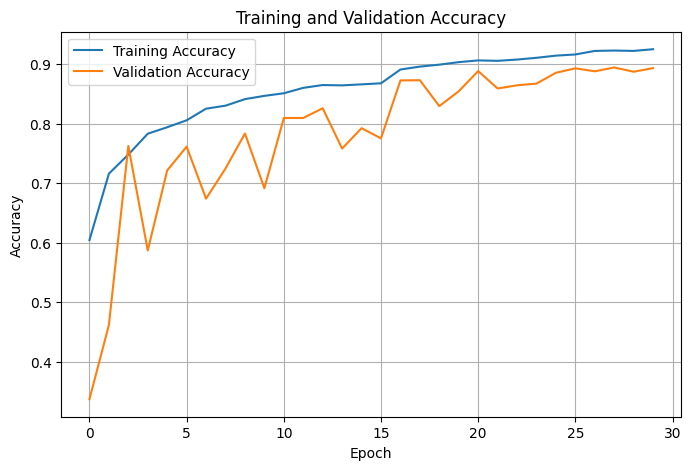

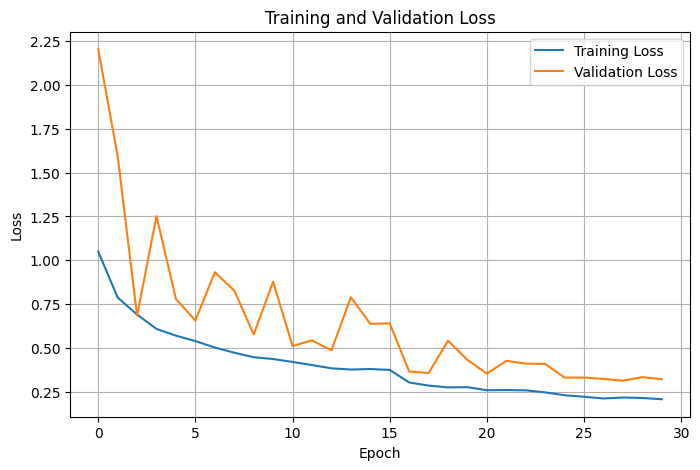

In [21]:
plt.figure(figsize=(8, 5))
plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
plt.title("Training and Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.title("Training and Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()

### 3. Prediksi untuk Classification Report

In [22]:
test_generator.reset()

y_prob = model.predict(test_generator)
y_pred = np.argmax(y_prob, axis=1)
y_true = test_generator.classes

class_labels = list(test_generator.class_indices.keys())

print(classification_report(y_true, y_pred, target_names=class_labels))

94/94 ━━━━━━━━━━━━━━━━━━━━ 12s 119ms/step
              precision    recall  f1-score   support

   buildings       0.82      0.92      0.86       437
      forest       0.98      0.96      0.97       474
     glacier       0.87      0.84      0.85       553
    mountain       0.84      0.84      0.84       525
         sea       0.87      0.92      0.90       510
      street       0.93      0.84      0.88       501

    accuracy                           0.88      3000
   macro avg       0.89      0.89      0.88      3000
weighted avg       0.89      0.88      0.88      3000



### 4. Confusion Matrix

<Figure size 800x800 with 0 Axes>

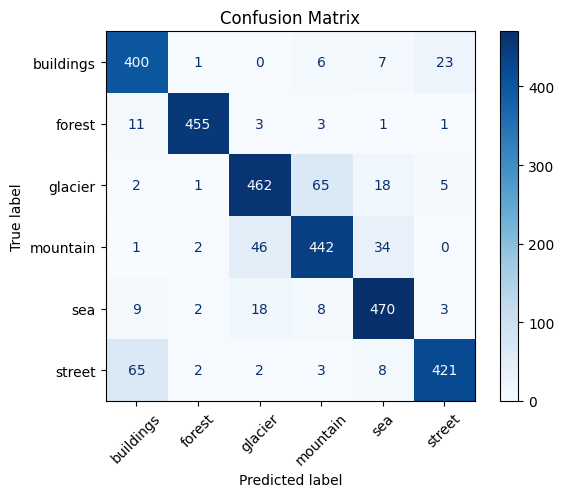

In [23]:
cm = confusion_matrix(y_true, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=class_labels
)

plt.figure(figsize=(8, 8))
disp.plot(cmap="Blues", values_format="d")
plt.title("Confusion Matrix")
plt.xticks(rotation=45)
plt.show()

## Ringkasan Hasil Model Baseline CNN

Model baseline CNN yang dibangun menggunakan arsitektur Sequential, Conv2D, MaxPooling2D, BatchNormalization, Dropout, dan Dense berhasil mencapai akurasi testing sebesar 88.33%. Hasil ini menunjukkan bahwa model telah memenuhi kriteria minimum akurasi 85% pada testing set.

In [24]:
baseline_model = model
baseline_test_loss = test_loss
baseline_test_accuracy = test_accuracy

print(f"Baseline CNN Test Loss     : {baseline_test_loss:.4f}")
print(f"Baseline CNN Test Accuracy : {baseline_test_accuracy:.4f}")

Baseline CNN Test Loss     : 0.3473
Baseline CNN Test Accuracy : 0.8833


## Pemilihan Model Final

Model CNN baseline dipilih sebagai model final karena telah memenuhi kriteria utama project, yaitu menggunakan Sequential, Conv2D, dan Pooling Layer, serta memperoleh akurasi testing di atas 85%.

In [25]:
final_model = model
final_model_name = "Custom CNN Baseline"
final_test_loss = test_loss
final_test_accuracy = test_accuracy
final_class_labels = class_labels

print("Model final:", final_model_name)
print(f"Final Test Loss     : {final_test_loss:.4f}")
print(f"Final Test Accuracy : {final_test_accuracy:.4f}")

Model final: Custom CNN Baseline
Final Test Loss     : 0.3473
Final Test Accuracy : 0.8833


## Penyimpanan Model Final

Model final disimpan ke dalam tiga format berbeda, yaitu SavedModel, TensorFlow Lite, dan TensorFlow.js. Penyimpanan dalam berbagai format ini dilakukan agar model dapat digunakan pada berbagai platform deployment.

Format yang digunakan:

1. **SavedModel** untuk deployment berbasis TensorFlow.
2. **TensorFlow Lite** untuk deployment pada perangkat mobile atau edge device.
3. **TensorFlow.js** untuk deployment pada aplikasi berbasis web.

Selain model, file label juga disimpan untuk memetakan output prediksi ke nama kelas.

In [26]:
for output_dir in [SAVED_MODEL_DIR, TFLITE_DIR, TFJS_DIR]:
    if output_dir.exists():
        shutil.rmtree(output_dir)
    output_dir.mkdir(parents=True, exist_ok=True)

print("Folder output model sudah disiapkan ulang.")

Folder output model sudah disiapkan ulang.


### Menyimpan Model ke Format SavedModel

SavedModel merupakan format standar TensorFlow yang menyimpan struktur model dan bobot model secara lengkap.

In [27]:
final_model.export(str(SAVED_MODEL_DIR))

print("SavedModel berhasil disimpan di:")
print(SAVED_MODEL_DIR)

Saved artifact at '/content/drive/MyDrive/natural_scene_classification_cnn/saved_model'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 150, 150, 3), dtype=tf.float32, name='keras_tensor')
Output Type:
  TensorSpec(shape=(None, 6), dtype=tf.float32, name=None)
Captures:
  135269335975696: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135269335977424: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135269335979344: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135269335977040: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135269335976848: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135269335978384: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135269335978960: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135269335979152: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135269335980880: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135269335981072: TensorSpec(shape

### Konversi Model ke Format TensorFlow Lite

Model final dikonversi ke format TensorFlow Lite agar dapat digunakan pada perangkat mobile atau perangkat dengan resource terbatas.

In [28]:
converter = tf.lite.TFLiteConverter.from_saved_model(str(SAVED_MODEL_DIR))
tflite_model = converter.convert()

tflite_path = TFLITE_DIR / "model.tflite"

with open(tflite_path, "wb") as file:
    file.write(tflite_model)

print("Model TFLite berhasil disimpan di:")
print(tflite_path)

Model TFLite berhasil disimpan di:
/content/drive/MyDrive/natural_scene_classification_cnn/tflite/model.tflite


### Menyimpan File Label

File label disimpan dalam format `.txt`. File ini berisi nama kelas sesuai urutan indeks output model.

In [29]:
label_path = TFLITE_DIR / "label.txt"

with open(label_path, "w") as file:
    for label in final_class_labels:
        file.write(label + "\n")

print("Label berhasil disimpan di:")
print(label_path)

print("\nDaftar label:")
for index, label in enumerate(final_class_labels):
    print(index, label)

Label berhasil disimpan di:
/content/drive/MyDrive/natural_scene_classification_cnn/tflite/label.txt

Daftar label:
0 buildings
1 forest
2 glacier
3 mountain
4 sea
5 street


### Menyimpan Model ke Format TensorFlow.js

Model final juga disimpan ke dalam format TensorFlow.js agar dapat digunakan pada aplikasi berbasis web.

In [31]:
!pip install -q tensorflowjs

import tensorflowjs as tfjs

tfjs.converters.save_keras_model(final_model, str(TFJS_DIR))

print("Model TensorFlow.js berhasil disimpan di:")
print(TFJS_DIR)

print("\nIsi folder tfjs_model:")
print(os.listdir(TFJS_DIR))

failed to lookup keras version from the file,
    this is likely a weight only file
Model TensorFlow.js berhasil disimpan di:
/content/drive/MyDrive/natural_scene_classification_cnn/tfjs_model

Isi folder tfjs_model:
['group1-shard1of1.bin', 'model.json']


### Validasi File Output Model

Tahap ini dilakukan untuk memastikan seluruh file model yang dibutuhkan telah berhasil dibuat.

In [32]:
print("Isi saved_model:")
print(os.listdir(SAVED_MODEL_DIR))

print("\nIsi tflite:")
print(os.listdir(TFLITE_DIR))

print("\nIsi tfjs_model:")
print(os.listdir(TFJS_DIR))

Isi saved_model:
['variables', 'assets', 'saved_model.pb', 'fingerprint.pb']

Isi tflite:
['model.tflite', 'label.txt']

Isi tfjs_model:
['group1-shard1of1.bin', 'model.json']


## Inference Model Final

Pada tahap ini dilakukan inference menggunakan model final terhadap beberapa gambar dari test set. Gambar diambil dari setiap kelas, kemudian model memprediksi label kelas beserta confidence score.

Tahap inference ini digunakan untuk memastikan bahwa model dapat menghasilkan output kelas kategorikal pada data gambar baru.

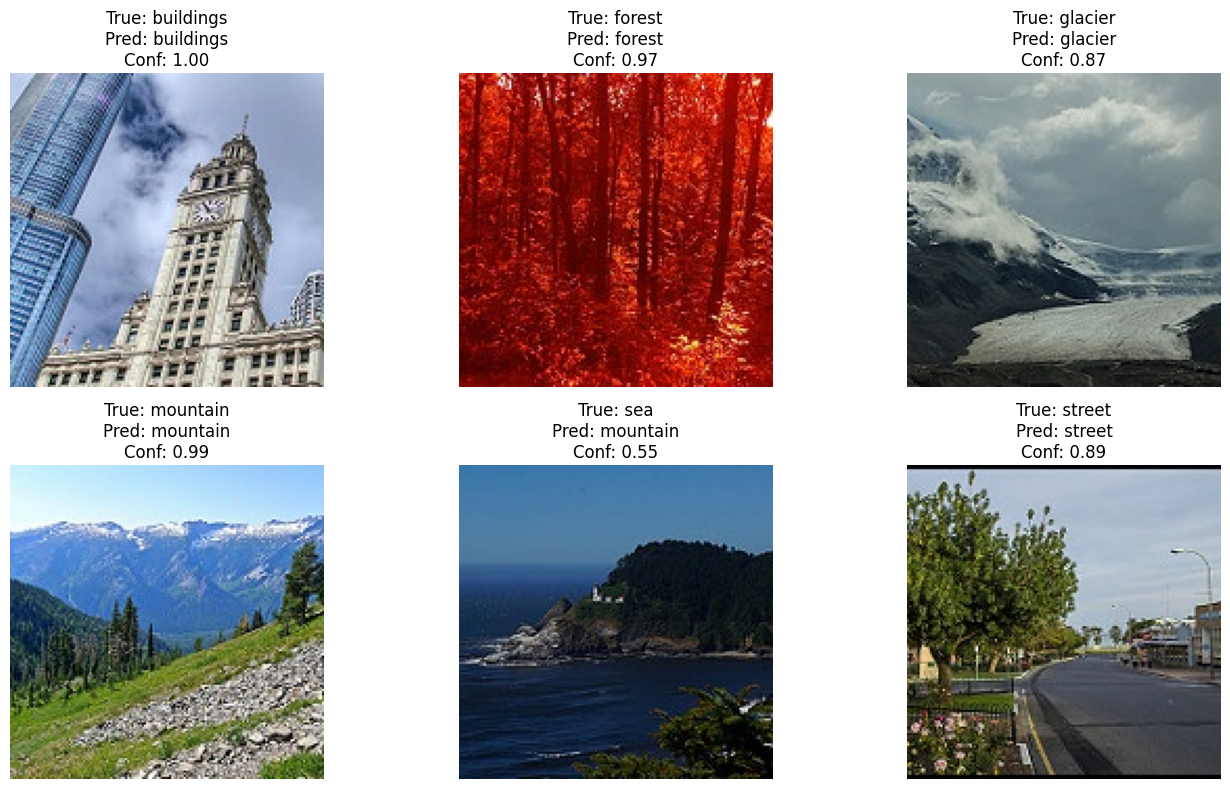

In [33]:
def load_and_preprocess_image(image_path):
    img = Image.open(image_path).convert("RGB")
    img = img.resize((150, 150))

    img_array = np.array(img) / 255.0
    img_array = np.expand_dims(img_array, axis=0)

    return img, img_array


sample_images = []

for class_name in final_class_labels:
    class_dir = TEST_DIR / class_name
    image_files = list(class_dir.glob("*.jpg"))

    if len(image_files) > 0:
        sample_images.append(random.choice(image_files))

plt.figure(figsize=(14, 8))

for i, image_path in enumerate(sample_images):
    original_img, img_array = load_and_preprocess_image(image_path)

    prediction = final_model.predict(img_array, verbose=0)
    predicted_index = np.argmax(prediction)
    predicted_label = final_class_labels[predicted_index]
    confidence = np.max(prediction)

    true_label = image_path.parent.name

    plt.subplot(2, 3, i + 1)
    plt.imshow(original_img)
    plt.axis("off")
    plt.title(
        f"True: {true_label}\nPred: {predicted_label}\nConf: {confidence:.2f}"
    )

plt.tight_layout()
plt.show()

## Kesimpulan

Project ini berhasil membangun model klasifikasi gambar untuk enam kelas natural scene, yaitu buildings, forest, glacier, mountain, sea, dan street.

Dataset yang digunakan memiliki 17.034 gambar, terdiri dari 14.034 gambar training dan 3.000 gambar testing. Dataset ini telah memenuhi kriteria project karena jumlah gambar jauh di atas minimum 1.000 gambar dan memiliki lebih dari 3 kelas.

Model CNN yang dibangun menggunakan arsitektur Sequential dengan Conv2D, MaxPooling2D, BatchNormalization, Dropout, dan Dense. Model berhasil mencapai test accuracy sebesar 88.33%, sehingga telah memenuhi kriteria minimum akurasi 85%.

Selain accuracy, model juga dievaluasi menggunakan classification report dan confusion matrix untuk melihat performa pada setiap kelas. Hasil evaluasi menunjukkan bahwa model mampu melakukan klasifikasi dengan performa yang cukup baik pada seluruh kelas.

Model final kemudian disimpan ke dalam format SavedModel, TensorFlow Lite, dan TensorFlow.js agar dapat digunakan pada berbagai platform deployment.

Secara keseluruhan, project ini telah memenuhi kriteria utama submission, yaitu penggunaan dataset gambar yang sesuai, pembagian data training-validation-testing, penggunaan CNN dengan Conv2D dan Pooling Layer, evaluasi model, visualisasi training, inference, serta penyimpanan model ke beberapa format deployment.